# AI/ML Task 1 — Development Environment, Python Foundations & Data Exploration

**Internship Domain:** Artificial Intelligence & Machine Learning (AI/ML)
**Task Title:** AI/ML Development Environment Setup, Python Foundations & Data Exploration

This notebook walks through Parts C–G of the task brief:
- Part C — Python Fundamentals (quick demo)
- Part D — Working with Data
- Part E — Exploratory Data Analysis
- Part F — Mini Project: Student Performance Data Explorer
- Part G — Advanced Challenge: Full EDA on the Iris dataset


## Setup — Imports

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from eda_utils import load_dataset, dataset_overview, clean_student_data, summary_stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
IMAGES_DIR = "../images"


## Part C — Python Fundamentals (quick demo)

A short demonstration of the core language features covered in this task:
variables, data types, operators, conditionals, loops, functions, lists,
tuples, dictionaries, sets, and file handling.

In [2]:
# Variables & data types
student_name = "Aditi"          # str
age = 20                        # int
gpa = 8.7                       # float
is_enrolled = True              # bool

# Operators & conditional statements
if gpa >= 8.0:
    status = "Distinction"
elif gpa >= 6.0:
    status = "First Class"
else:
    status = "Pass"

print(f"{student_name} ({age}) -> GPA {gpa}: {status}")

# Loops + list
scores = [78, 85, 92, 60, 74]
above_80 = []
for s in scores:
    if s >= 80:
        above_80.append(s)
print("Scores >= 80:", above_80)

# Function
def average(nums):
    return sum(nums) / len(nums)

print("Average score:", round(average(scores), 2))

# Tuple, dict, set
coordinates = (12.9716, 77.5946)          # tuple (lat, long)
student_record = {"name": student_name, "gpa": gpa}   # dict
unique_grades = {"A", "B", "A", "C"}       # set -> duplicates removed
print(coordinates, student_record, unique_grades)

# File handling
with open("../reports/sample_notes.txt", "w") as f:
    f.write("Task 1 fundamentals demo complete.\n")
with open("../reports/sample_notes.txt", "r") as f:
    print(f.read())


Aditi (20) -> GPA 8.7: Distinction
Scores >= 80: [85, 92]
Average score: 77.8
(12.9716, 77.5946) {'name': 'Aditi', 'gpa': 8.7} {'C', 'A', 'B'}
Task 1 fundamentals demo complete.



## Part D — Working with Data
## Part F — Mini Project: Student Performance Data Explorer

**Problem statement:** analyze student performance data to identify
patterns in scores, study habits, and attendance, and present findings
through visualizations.

### D.1 — Read CSV & display the dataset

In [3]:
df_raw = load_dataset("../data/student_data.csv")
df_raw.head(10)

,Student ID,Name,Gender,Study Hours,Attendance (%),Math Score,Reading Score,Writing Score
0,1280,Student_280,Female,6.7,91.2,97.5,100.0,100.0
1,1103,Student_103,Female,2.8,90.0,81.4,95.2,90.0
2,1172,Student_172,Male,1.1,87.5,83.2,74.3,82.5
3,1171,Student_171,Female,7.2,86.8,100.0,89.1,94.6
4,1074,Student_74,Female,3.9,74.2,85.6,78.7,89.3
5,1265,Student_265,Male,7.3,94.4,94.7,100.0,94.2
6,1133,Student_133,Male,3.3,NaN,84.8,70.0,73.3
7,1160,Student_160,Female,4.0,82.8,78.9,79.3,79.2
8,1038,Student_38,Male,4.5,94.6,79.8,89.0,76.4
9,1082,Student_82,Female,4.6,90.4,98.6,84.5,91.1


### D.2 — Explore columns & structure

In [4]:
dataset_overview(df_raw)

Shape: 310 rows x 8 columns

Column dtypes:
Student ID          int64
Name                  str
Gender                str
Study Hours       float64
Attendance (%)    float64
Math Score        float64
Reading Score     float64
Writing Score     float64
dtype: object 

Missing values per column:
Student ID         0
Name               0
Gender             0
Study Hours        0
Attendance (%)    15
Math Score        15
Reading Score     15
Writing Score      0
dtype: int64 

Duplicate rows: 10


### D.3 — View missing values

In [5]:
missing = df_raw.isnull().sum()
missing[missing > 0]

Attendance (%)    15
Math Score        15
Reading Score     15
dtype: int64

### D.4 — Remove duplicates & rename columns (cleaning)

In [6]:
df = clean_student_data(df_raw)
print(f"Rows before cleaning: {len(df_raw)}  |  Rows after cleaning: {len(df)}")
df.head()

Rows before cleaning: 310  |  Rows after cleaning: 300


,student_id,name,gender,study_hours,attendance_pct,math_score,reading_score,writing_score
0,1280,Student_280,Female,6.7,91.2,97.5,100.0,100.0
1,1103,Student_103,Female,2.8,90.0,81.4,95.2,90.0
2,1172,Student_172,Male,1.1,87.5,83.2,74.3,82.5
3,1171,Student_171,Female,7.2,86.8,100.0,89.1,94.6
4,1074,Student_74,Female,3.9,74.2,85.6,78.7,89.3


## Part E — Exploratory Data Analysis

### E.1 — Descriptive statistics (mean, median, mode, spread)

In [7]:
stats = summary_stats(df[["study_hours", "attendance_pct", "math_score", "reading_score", "writing_score"]])
stats["mode"] = df[["study_hours","attendance_pct","math_score","reading_score","writing_score"]].mode().iloc[0]
stats

,count,mean,std,min,25%,50%,75%,max,mode
study_hours,300.0,4.080000,1.438110,0.0,3.000,4.10,5.000,9.8,2.8
attendance_pct,300.0,84.302333,9.560836,58.0,77.875,84.40,91.225,100.0,100.0
math_score,300.0,85.644000,10.101131,53.1,78.975,86.00,93.625,100.0,100.0
reading_score,300.0,81.106333,10.609086,52.0,73.575,80.70,89.600,100.0,100.0
writing_score,300.0,82.972333,10.446590,53.2,75.150,83.45,91.400,100.0,100.0


### E.2 — Average marks by gender

In [8]:
df.groupby("gender")[["math_score", "reading_score", "writing_score"]].mean().round(2)

,math_score,reading_score,writing_score
gender,,,
Female,85.46,81.47,83.04
Male,85.83,80.75,82.91


### E.3 — Correlation matrix & heatmap

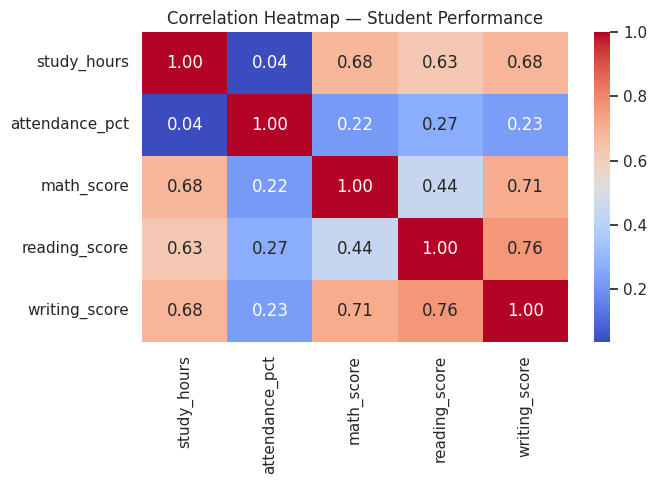

In [9]:
numeric_cols = ["study_hours", "attendance_pct", "math_score", "reading_score", "writing_score"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Student Performance")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/student_correlation_heatmap.png", dpi=150)
plt.show()

### E.4 — Histograms of scores

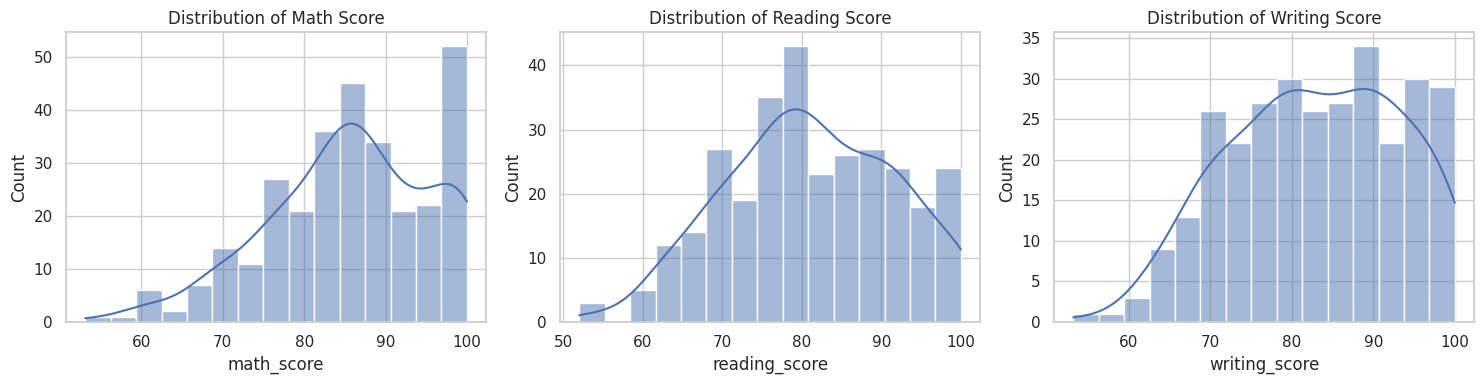

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["math_score", "reading_score", "writing_score"]):
    sns.histplot(df[col], bins=15, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col.replace('_', ' ').title()}")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/student_score_histograms.png", dpi=150)
plt.show()

### E.5 — Scatter plot: Study hours vs Math score

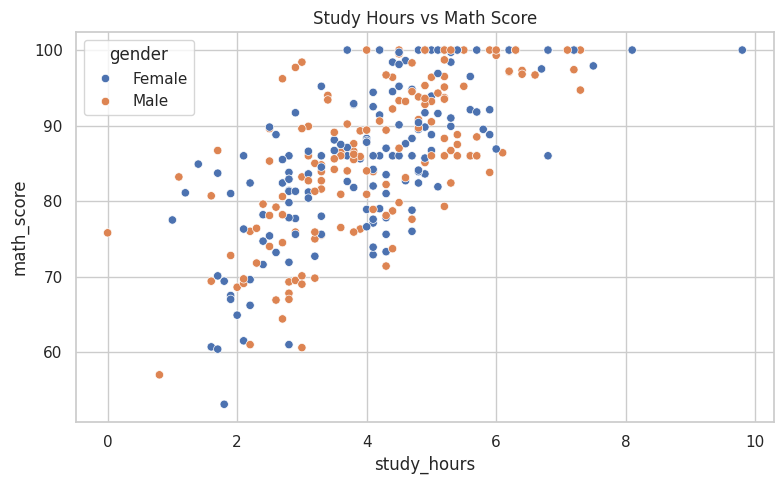

In [11]:
plt.figure()
sns.scatterplot(data=df, x="study_hours", y="math_score", hue="gender")
plt.title("Study Hours vs Math Score")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/student_studyhours_vs_math.png", dpi=150)
plt.show()

### E.6 — Box plots (outlier detection)

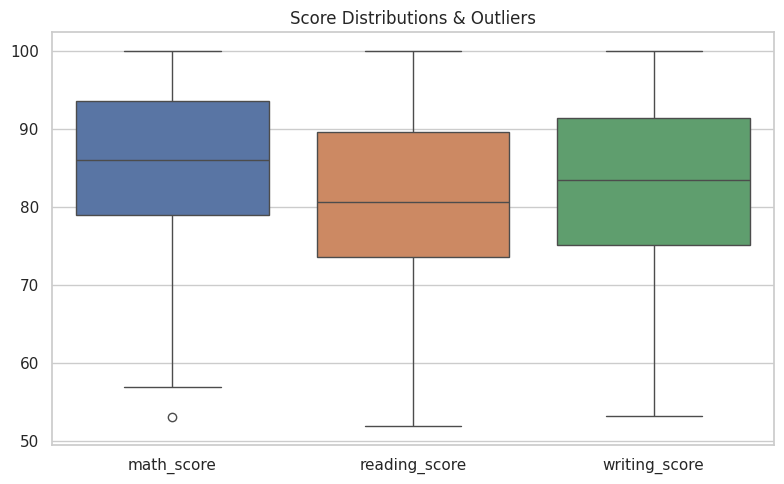

In [12]:
plt.figure()
sns.boxplot(data=df[["math_score", "reading_score", "writing_score"]])
plt.title("Score Distributions & Outliers")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/student_boxplots.png", dpi=150)
plt.show()

### E.7 — Key insights (Student Performance)

- **Study hours and attendance both correlate positively with scores** — students who study more and attend more classes tend to score higher across all three subjects.
- **Reading and writing scores are the most tightly correlated pair**, which matches how the scores were derived and mirrors real-world patterns (verbal skills tend to move together).
- **No extreme outliers** were found in the box plots after cleaning; the interquartile ranges are consistent across subjects.
- **Gender differences in average scores are small**, suggesting study habits and attendance are stronger predictors of performance than gender in this dataset.


## Part G — Advanced Challenge: Full EDA on the Iris Dataset

### G.1 — Load & inspect

In [13]:
iris = load_dataset("../data/iris.csv")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
dataset_overview(iris)

Shape: 150 rows x 5 columns

Column dtypes:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object 

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64 

Duplicate rows: 1


### G.2 — Descriptive statistics per species

In [15]:
iris.groupby("species").agg(["mean", "median"]).round(2)

sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa             5.01    5.0        3.43    3.4         1.46   1.50   
versicolor         5.94    5.9        2.77    2.8         4.26   4.35   
virginica          6.59    6.5        2.97    3.0         5.55   5.55   

           petal_width         
                  mean median  
species                        
setosa            0.25    0.2  
versicolor        1.33    1.3  
virginica         2.03    2.0

### G.3 — Correlation heatmap

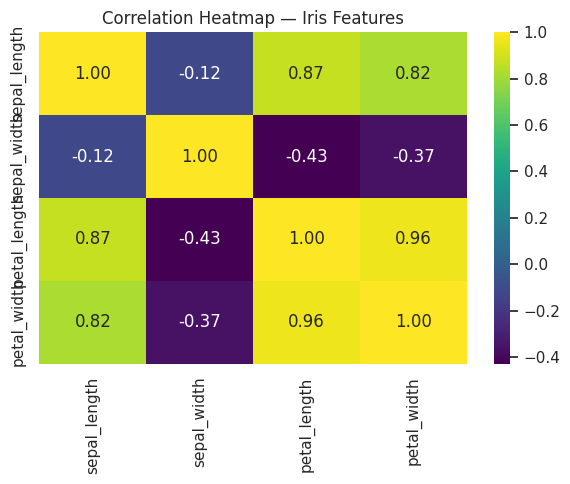

In [16]:
iris_numeric = iris.drop(columns=["species"])
plt.figure(figsize=(6, 5))
sns.heatmap(iris_numeric.corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap — Iris Features")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/iris_correlation_heatmap.png", dpi=150)
plt.show()

### G.4 — Histograms by feature

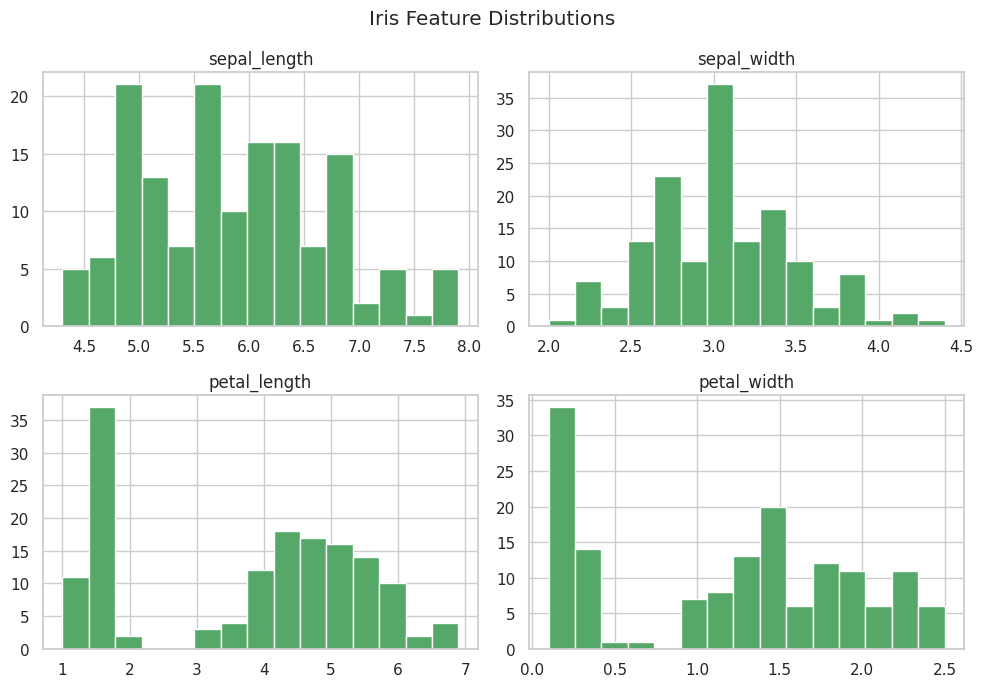

In [17]:
iris_numeric.hist(bins=15, figsize=(10, 7), color="#55A868")
plt.suptitle("Iris Feature Distributions")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/iris_histograms.png", dpi=150)
plt.show()

### G.5 — Scatter plot: petal length vs petal width, by species

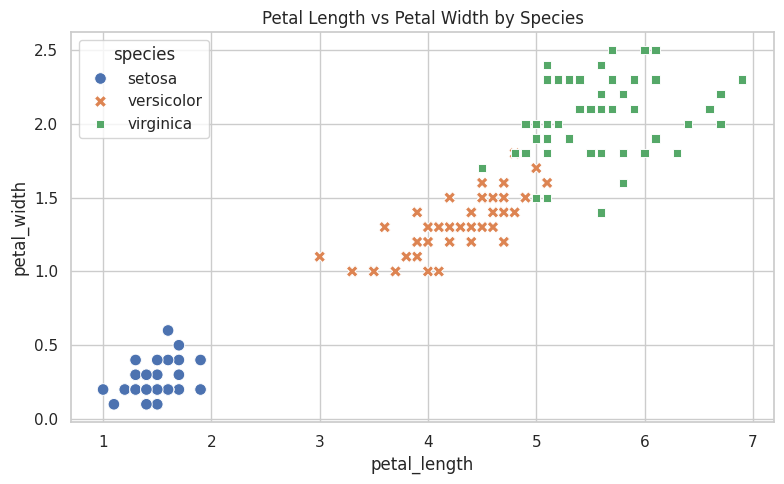

In [18]:
plt.figure()
sns.scatterplot(data=iris, x="petal_length", y="petal_width", hue="species", style="species", s=70)
plt.title("Petal Length vs Petal Width by Species")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/iris_scatter_petal.png", dpi=150)
plt.show()

### G.6 — Box plots by species

/tmp/ipykernel_549/3789140208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x="species", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_549/3789140208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x="species", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_549/3789140208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x="species", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_549/3789140208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0

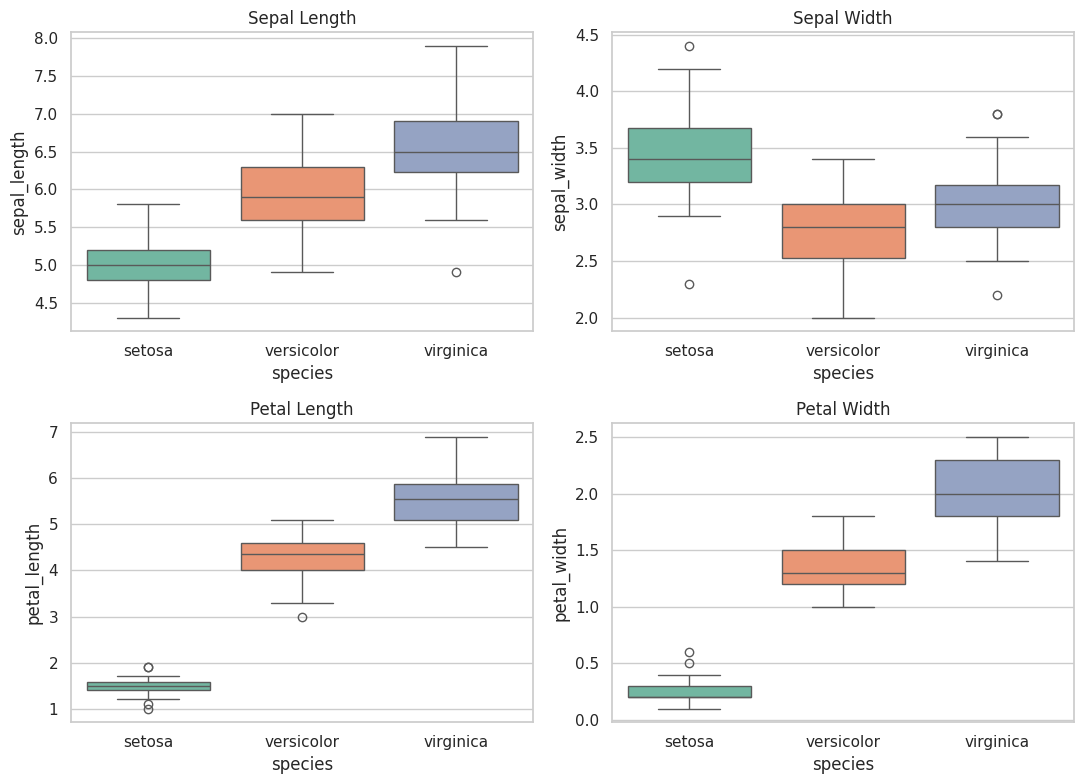

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, iris_numeric.columns):
    sns.boxplot(data=iris, x="species", y=col, ax=ax, palette="Set2")
    ax.set_title(col.replace("_", " ").title())
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/iris_boxplots_by_species.png", dpi=150)
plt.show()

### G.7 — Pairplot

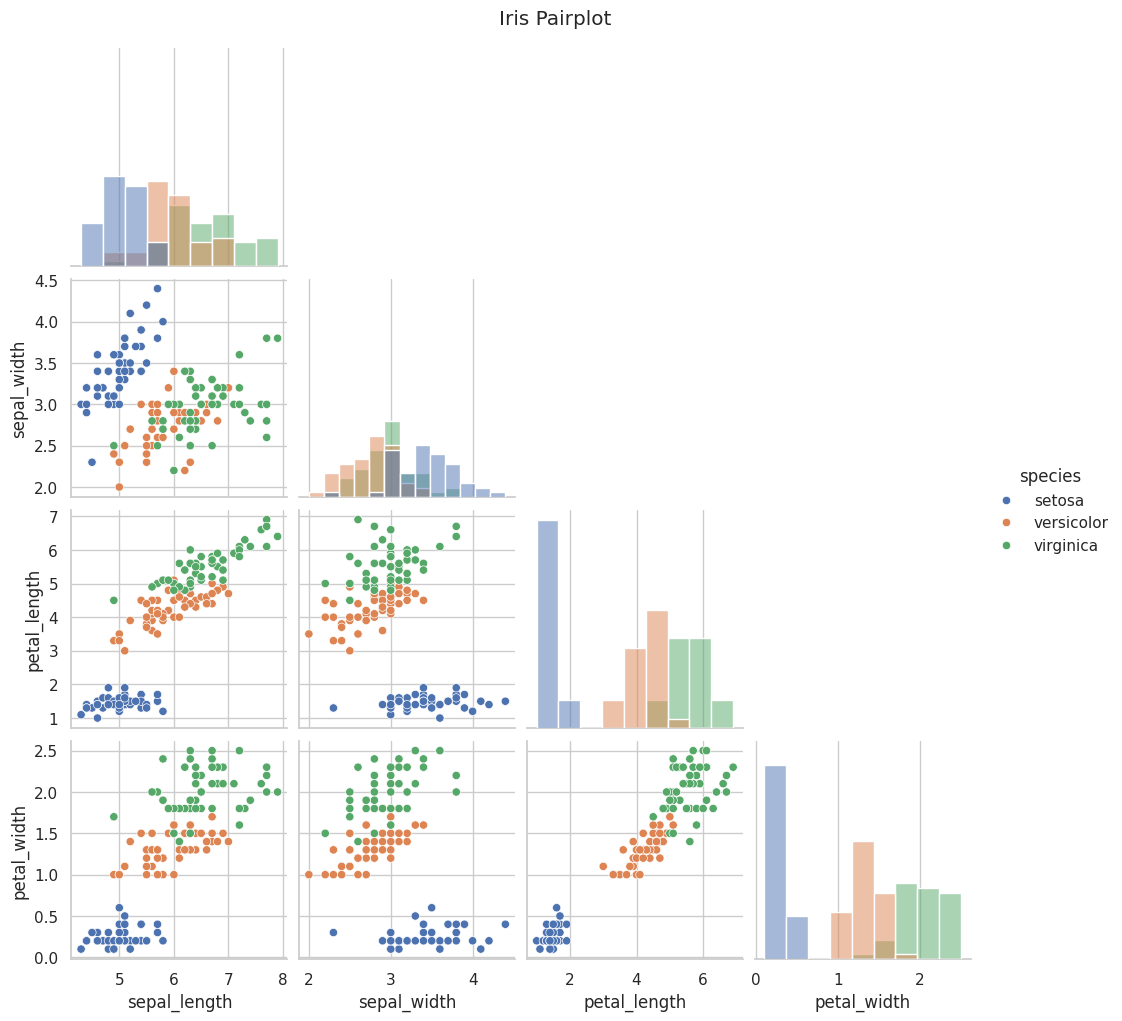

In [20]:
pp = sns.pairplot(iris, hue="species", diag_kind="hist", corner=True)
pp.fig.suptitle("Iris Pairplot", y=1.02)
pp.savefig(f"{IMAGES_DIR}/iris_pairplot.png", dpi=150)
plt.show()

### G.8 — Key insights (Iris)

- **Petal length and petal width are almost perfectly correlated** and are by far the strongest predictors of species — far more useful than sepal measurements.
- **Setosa is linearly separable** from the other two species on petal measurements alone; a simple threshold on petal length/width would classify it with near-zero error.
- **Versicolor and virginica overlap slightly** in petal dimensions, meaning a classifier will need more than a single feature (or a nonlinear boundary) to separate them perfectly.
- **Sepal width has the weakest, even slightly negative, correlation with the other features**, making it the least informative single feature for species prediction.

These patterns are exactly why petal measurements dominate feature importance in classic Iris classification models — a preview of what Task 2 will build on.


## Summary

This notebook covered the full Task 1 workflow: environment-ready Python
fundamentals, loading and cleaning a real-world-style dataset with missing
values and duplicates, descriptive statistics, and a full suite of EDA
visualizations (histograms, scatter plots, box plots, heatmaps, pairplot)
across two datasets. The cleaned `student_data.csv` and the `iris.csv`
dataset are both ready to feed into Task 2 (baseline model training).
